In [60]:
import pandas as pd
import numpy as np
df=pd.read_csv(r"/content/college_student_placement_dataset.csv")

In [61]:
df.shape

(10000, 10)

In [62]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement'],
      dtype='object')

In [63]:
df.describe()

,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,99.471800,7.535673,7.532379,5.546400,4.970900,5.561800,2.513400
std,15.053101,1.447519,1.470141,2.873477,3.160103,2.900866,1.715959
min,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,99.000000,7.560000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,110.000000,8.790000,8.770000,8.000000,8.000000,8.000000,4.000000
max,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [64]:
df.isnull().sum()

,0
College_ID,0
IQ,0
Prev_Sem_Result,0
CGPA,0
Academic_Performance,0
Internship_Experience,0
Extra_Curricular_Score,0
Communication_Skills,0
Projects_Completed,0
Placement,0


In [65]:
df.duplicated().sum()

np.int64(0)

In [66]:
df.tail(5)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
9995,CLG0021,119,8.41,8.29,4,No,1,8,0,Yes
9996,CLG0098,70,9.25,9.34,7,No,0,7,2,No
9997,CLG0066,89,6.08,6.25,3,Yes,3,9,5,No
9998,CLG0045,107,8.77,8.92,3,No,7,5,1,No
9999,CLG0060,109,9.41,9.77,8,No,3,5,5,No


nearly 249 data have more than 10 cgpa leads to reduce the quality of analysis

In [67]:
df[df['CGPA'] > 10]

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
17,CLG0050,104,9.61,10.01,10,Yes,9,2,4,No
119,CLG0058,111,9.92,10.37,1,No,4,5,1,No
127,CLG0057,91,9.76,10.17,2,No,2,8,0,No
178,CLG0056,96,9.72,10.07,7,No,9,5,2,No
206,CLG0040,107,9.79,10.02,9,No,4,6,5,No
...,...,...,...,...,...,...,...,...,...,...
9903,CLG0051,99,9.92,10.28,6,No,10,9,5,Yes
9933,CLG0037,89,9.98,10.05,9,Yes,8,1,0,No
9953,CLG0069,85,9.70,10.02,9,No,2,4,2,No
9964,CLG0090,123,9.93,10.01,6,No,0,4,5,Yes


In [73]:
df = df[df['CGPA'] <= 10]

In [74]:
df.shape

(9751, 10)

check for previous sem result

In [75]:
(df['Prev_Sem_Result'] > 10).sum()

np.int64(0)

In [76]:
(df['IQ'] > 160).sum()

np.int64(0)

In [77]:
(df['IQ'] <=0).sum()

np.int64(0)

convert non-numerical values into numerical values

In [78]:
df.head(2)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,No,8,8,4,No
1,CLG0061,97,5.52,5.37,8,No,7,8,0,No


In [79]:
df['Placement'] = df['Placement'].map({'Yes': 1, 'No': 0})

In [81]:
df['Internship_Experience'] = df['Internship_Experience'].map({'Yes': 1, 'No': 0})

In [82]:
df.head(5)

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0
1,CLG0061,97,5.52,5.37,8,0,7,8,0,0
2,CLG0036,109,5.36,5.83,9,0,3,1,1,0
3,CLG0055,122,5.47,5.75,6,1,1,6,1,0
4,CLG0004,96,7.91,7.69,7,0,8,10,2,0


CHECK HOW MANY STUDENTS INTERESTED TOWARS PLACEMENT

In [83]:
(df['Placement'] == 1).sum()

np.int64(1575)

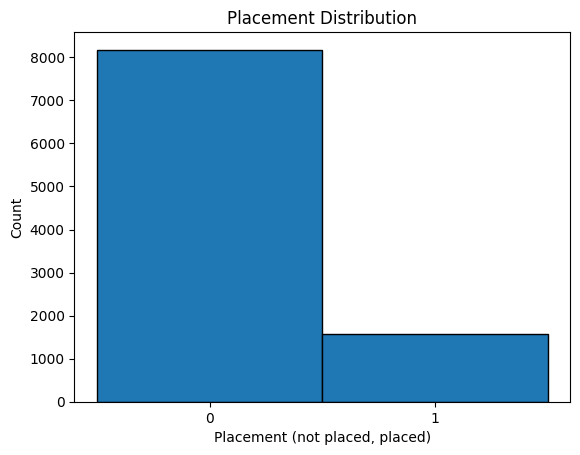

In [120]:
import matplotlib.pyplot as plt


plt.hist(df['Placement'], bins=[-0.5, 0.5, 1.5], edgecolor='black')
plt.xticks([0, 1])
plt.xlabel("Placement (not placed, placed)")
plt.ylabel("Count")
plt.title("Placement Distribution")
plt.show()

ANALYSIS OF IMPROVED STUDENTS

In [121]:
df['improved'] = df['CGPA'] > df['Prev_Sem_Result']

In [122]:
df['improved'].sum()

np.int64(4660)

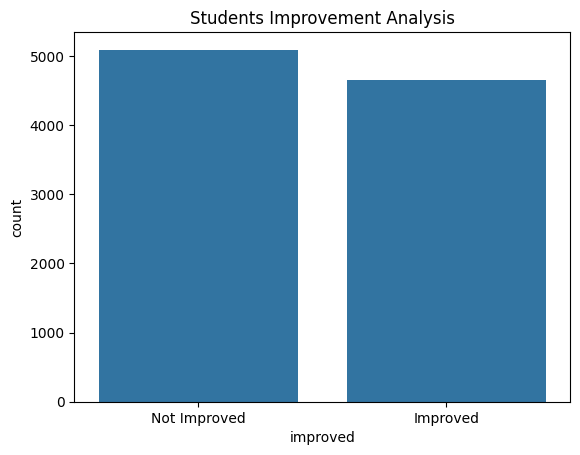

In [90]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='improved', data=df)
plt.xticks([0, 1], ['Not Improved', 'Improved'])
plt.title("Students Improvement Analysis")
plt.show()

CHECK FOR STUDENT WHO HAS CGPA MORE THAN 7 AND SAY YES TO PLACEMENT

In [123]:
result_df = df[(df['Placement'] == 0) & (df['CGPA'] > 7)]
len(result_df)

4461

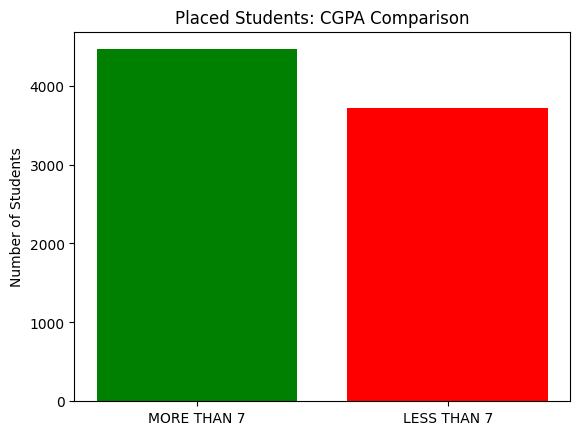

In [124]:


placed = df[df['Placement'] == 0]

more_7 = len(placed[placed['CGPA'] > 7])
less_eq_7 = len(placed[placed['CGPA'] <= 7])

labels = ['MORE THAN 7', 'LESS THAN 7']
values = [more_7, less_eq_7]
colors = ['green', 'red']

plt.bar(labels, values, color=colors)

plt.title("Placed Students: CGPA Comparison")
plt.ylabel("Number of Students")
plt.show()

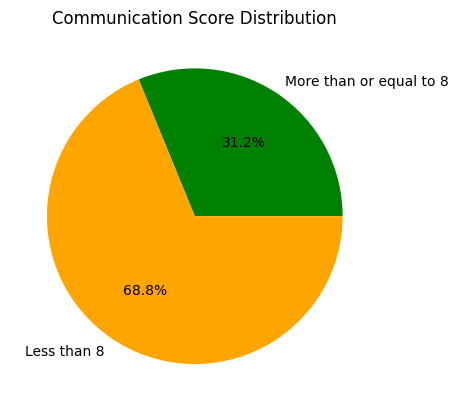

In [105]:
more_eq_8 = len(df[df['Communication_Skills'] >= 8])
less_8 = len(df[df['Communication_Skills'] < 8])

labels = ['More than or equal to 8', 'Less than 8']
values = [more_eq_8, less_8]
colors = ['green', 'orange']

plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors)
plt.title("Communication Score Distribution")
plt.show()

In [125]:
result_df = df[
    (df['Placement'] == 0) &
    (df['Projects_Completed'] >= 2) &
    (df['Academic_Performance'] >= 8)
]

result_df

,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement,improved,category
0,CLG0030,107,6.61,6.28,8,0,8,8,4,0,False,False
8,CLG0097,92,6.47,6.33,9,0,7,8,5,0,False,False
11,CLG0077,93,6.23,6.51,8,0,5,7,4,0,True,False
30,CLG0077,90,9.68,9.58,9,1,10,1,4,0,False,False
33,CLG0018,84,6.29,6.51,8,0,8,7,4,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
9968,CLG0073,100,8.73,8.75,8,1,3,7,5,0,True,False
9979,CLG0025,73,6.11,5.76,9,1,6,2,4,0,False,False
9989,CLG0001,88,6.56,6.49,8,1,9,10,2,0,False,False
9990,CLG0046,121,5.58,5.27,9,0,7,3,2,0,False,False


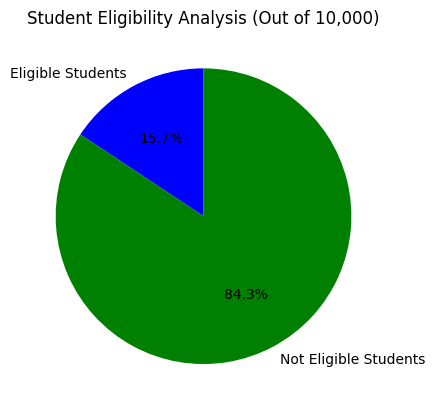

In [126]:


eligible = df[
    (df['Placement'] == 0) &
    (df['Projects_Completed'] >= 2) &
    (df['Academic_Performance'] >= 8)
]

count_eligible = len(eligible)
count_total = len(df)
count_not_eligible = count_total - count_eligible

labels = ['Eligible Students', 'Not Eligible Students']
values = [count_eligible, count_not_eligible]
colors = ['BLUE', 'GREEN']

plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title("Student Eligibility Analysis (Out of 10,000)")
plt.show()

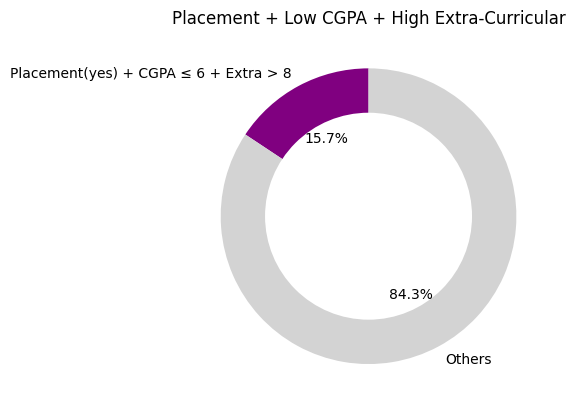

In [127]:
import matplotlib.pyplot as plt

total = len(df)
selected = len(result_df)
others = total - selected

labels = ['not plaved + CGPA ≤ 6 + Extra > 8', 'Others']
values = [selected, others]
colors = ['purple', 'lightgray']

plt.pie(values, labels=labels, autopct='%1.1f%%', colors=colors, startangle=90)

# Donut effect
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Placement + Low CGPA + High Extra-Curricular")
plt.show()

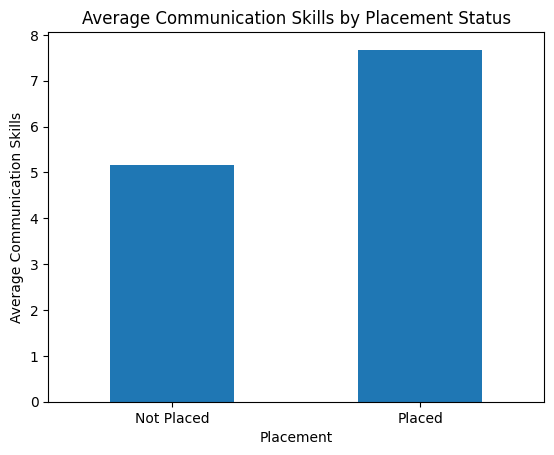

In [119]:
import matplotlib.pyplot as plt

avg_scores = df.groupby('Placement')['Communication_Skills'].mean()

avg_scores.plot(kind='bar')
plt.title('Average Communication Skills by Placement Status')
plt.xlabel('Placement')
plt.ylabel('Average Communication Skills')
plt.xticks([0,1], ['placement(no)', 'Placed'], rotation=0)
plt.show()

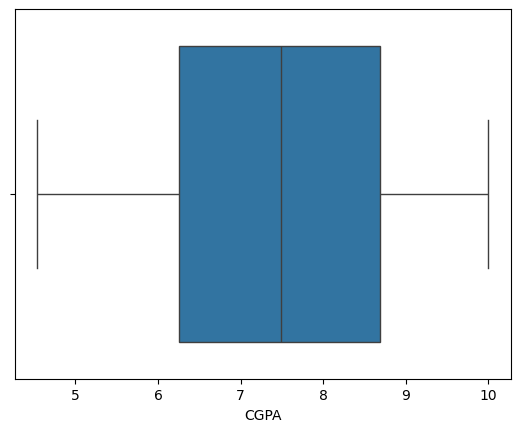

In [116]:
import seaborn as sns

sns.boxplot(x=df['CGPA'])
plt.show()

In [117]:
Q1 = df['CGPA'].quantile(0.25)
Q3 = df['CGPA'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

print("Lower Bound:", lower)
print("Upper Bound:", upper)

outliers = df[(df['CGPA'] < lower) | (df['CGPA'] > upper)]
print("Number of Outliers:", len(outliers))

Lower Bound: 2.615
Upper Bound: 12.334999999999999
Number of Outliers: 0


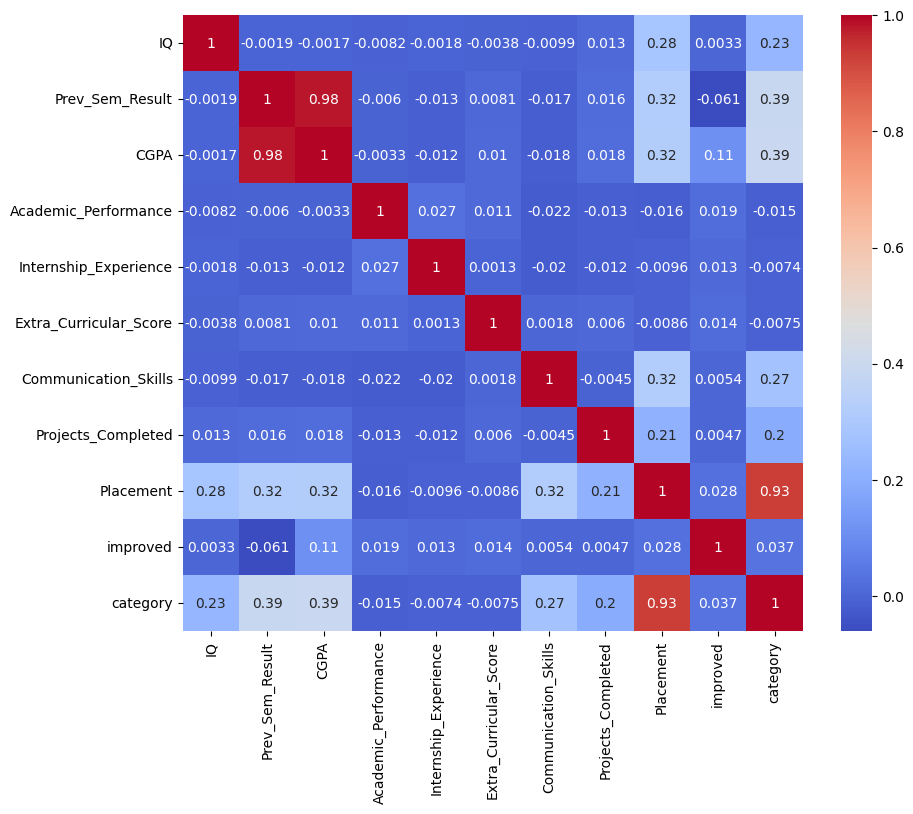

In [128]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()